# Chapter 12 example: total unimodularity through min-cost flow

The node--arc incidence matrix of a directed graph is totally unimodular. With integral supplies/demands and integral capacity bounds, every vertex of the flow polytope is integral. Consequently a linear program solves the corresponding integer min-cost-flow problem without an integrality gap.

This example emphasizes a different route to MAP-LP exactness from submodularity: exactness comes from the **constraint matrix**, independently of the particular linear edge costs.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from itertools import product
from scipy.optimize import minimize, linprog

CWD=Path.cwd()
NOTEBOOK_DIR=CWD if CWD.name.startswith('ch') else CWD/'notebooks'/CWD.name if False else CWD
if not (NOTEBOOK_DIR/'figs').exists() and (CWD/'notebooks').exists():
    # infer chapter directory from notebook working directory only when launched at repo root
    raise RuntimeError('Run this notebook from its chapter directory, e.g. notebooks/ch10/.')
FIG_DIR=NOTEBOOK_DIR/'figs'; FIG_DIR.mkdir(parents=True,exist_ok=True)
RNG=np.random.default_rng(577)
NODE_COLOR='#34495e'
plt.rcParams.update({'font.size':14,'axes.titlesize':17,'axes.labelsize':15,'xtick.labelsize':12,'ytick.labelsize':12,'legend.fontsize':12})
def save_figure(fig,stem):
    fig.savefig(FIG_DIR/f'{stem}.pdf',bbox_inches='tight')
    fig.savefig(FIG_DIR/f'{stem}.png',dpi=220,bbox_inches='tight')

optimal cost 32.0
flows [ 3.  2.  2.  1.  4.  0.  5. -0.]
integral? True


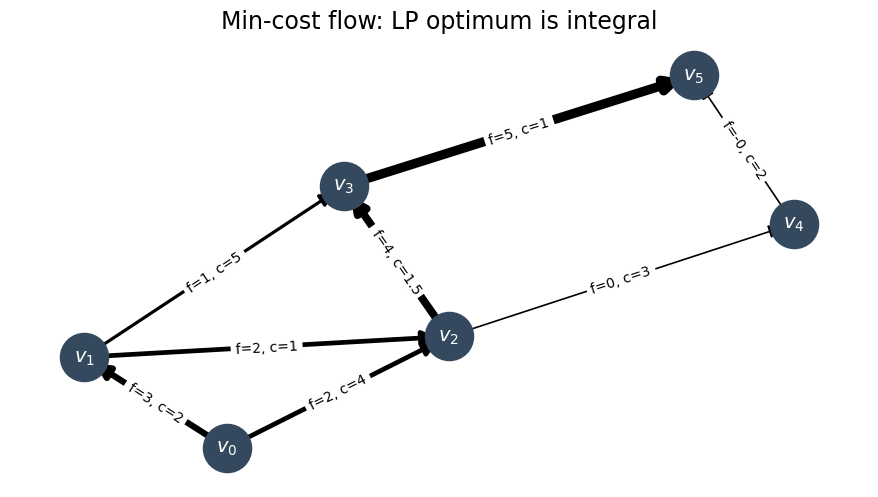

In [2]:
nodes=list(range(6)); edges=[(0,1),(0,2),(1,2),(1,3),(2,3),(2,4),(3,5),(4,5)]
cost=np.array([2.,4.,1.,5.,1.5,3.,1.,2.]); cap=np.array([4,4,2,4,4,3,5,4],float)
b=np.array([5,0,0,0,0,-5],float) # net outflow convention
A=np.zeros((len(nodes),len(edges)))
for k,(u,v) in enumerate(edges): A[u,k]=1; A[v,k]=-1
# remove one redundant conservation row
res=linprog(cost,A_eq=A[:-1],b_eq=b[:-1],bounds=list(zip(np.zeros(len(edges)),cap)),method='highs')
assert res.success
print('optimal cost',res.fun); print('flows',np.round(res.x,8)); print('integral?',np.allclose(res.x,np.round(res.x)))
G=nx.DiGraph(); G.add_nodes_from(nodes); G.add_edges_from(edges); pos=nx.spring_layout(G,seed=8)
fig,ax=plt.subplots(figsize=(9,5.2)); nx.draw_networkx_nodes(G,pos,node_color=NODE_COLOR,node_size=1200,ax=ax); nx.draw_networkx_labels(G,pos,labels={i:rf'$v_{i}$' for i in nodes},font_color='white',font_size=14,ax=ax); nx.draw_networkx_edges(G,pos,arrows=True,arrowsize=20,width=[1.2+1.1*x for x in res.x],ax=ax); nx.draw_networkx_edge_labels(G,pos,edge_labels={e:f'f={res.x[k]:.0f}, c={cost[k]:g}' for k,e in enumerate(edges)},font_size=10,ax=ax); ax.set_title('Min-cost flow: LP optimum is integral'); ax.axis('off'); fig.tight_layout(); save_figure(fig,'ch12_02_min_cost_flow'); plt.show()

In [3]:
# Spot-check total unimodularity by enumerating square minors for this small incidence matrix.
from itertools import combinations
maxdet=0; bad=[]
for r in range(1,min(A.shape)+1):
 for rs in combinations(range(A.shape[0]),r):
  for cs in combinations(range(A.shape[1]),r):
   det=round(np.linalg.det(A[np.ix_(rs,cs)]))
   maxdet=max(maxdet,abs(det))
   if abs(det)>1: bad.append((rs,cs,det))
print('largest absolute square-minor determinant:',maxdet,'; violations:',len(bad))
assert not bad

largest absolute square-minor determinant: 1 ; violations: 0


## Exercises

1. Randomize the edge costs while keeping the same constraints. Verify that the LP solution stays integral.
2. Replace the integral demand $5$ by $4.5$. Which part of the integrality theorem no longer applies?
3. **Challenge.** Rewrite the min-cost flow as a factor graph with flow variables on edges and conservation factors on nodes. Relate the LP constraints to the local-polytope formulation of MAP.